In [1]:
import xarray as xr
import matplotlib.pyplot as plt
from cmocean import cm as cmo
import cartopy
from mpl_toolkits.axes_grid1.inset_locator import mark_inset
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# Volta

In [3]:
#inspect data
FS = xr.open_dataset("C:/Users/rjvanderent/Documents/Moisture tracking/example-input-volta/preprocessed_data/1998-07-01_fluxes_storages.nc")
FS

<xarray.Dataset>
Dimensions:         (time: 24, latitude: 161, longitude: 281, bnds: 2)
Coordinates:
  * longitude       (longitude) float32 -30.0 -29.75 -29.5 ... 39.5 39.75 40.0
  * latitude        (latitude) float32 40.0 39.75 39.5 39.25 ... 0.5 0.25 0.0
  * time            (time) datetime64[ns] 1998-07-01 ... 1998-07-01T23:00:00
Dimensions without coordinates: bnds
Data variables:
    fx_upper        (time, latitude, longitude) float32 ...
    fy_upper        (time, latitude, longitude) float32 ...
    fx_lower        (time, latitude, longitude) float32 ...
    fy_lower        (time, latitude, longitude) float32 ...
    s_upper         (time, latitude, longitude) float32 ...
    s_lower         (time, latitude, longitude) float32 ...
    evap            (time, latitude, longitude) float32 ...
    precip          (time, latitude, longitude) float32 ...
    latitude_bnds   (latitude, bnds) float32 ...
    longitude_bnds  (longitude, bnds) float32 ...
Attributes:
    title:        ERA5 data preprocessed for use in WAM2layers
    history:      created on 2024-10-17T12:12:01Z using wam2layers version 3....
    source:       ECMWF Reanalysis v5 (ERA5), www.ecmwf.int/en/forecasts/data...
    references:   doi.org/10.5281/zenodo.7010594, doi.org/10.5194/esd-5-471-2014
    Conventions:  CF-1.6

In [4]:
OUT = xr.open_mfdataset("C:/Users/rjvanderent/Documents/Moisture tracking/example-input-volta/output_data/forwardtrack_1998-07-02T00-00.nc")
OUT

<xarray.Dataset>
Dimensions:                (longitude: 281, latitude: 161, time: 1, bnds: 2)
Coordinates:
  * longitude              (longitude) float32 -30.0 -29.75 -29.5 ... 39.75 40.0
  * latitude               (latitude) float32 40.0 39.75 39.5 ... 0.5 0.25 0.0
  * time                   (time) datetime64[ns] 1998-07-02
Dimensions without coordinates: bnds
Data variables:
    s_track_upper_restart  (time, latitude, longitude) float32 dask.array<chunksize=(1, 161, 281), meta=np.ndarray>
    s_track_lower_restart  (time, latitude, longitude) float32 dask.array<chunksize=(1, 161, 281), meta=np.ndarray>
    p_track_upper          (time, latitude, longitude) float32 dask.array<chunksize=(1, 161, 281), meta=np.ndarray>
    p_track_lower          (time, latitude, longitude) float32 dask.array<chunksize=(1, 161, 281), meta=np.ndarray>
    tagged_evap            (time, latitude, longitude) float32 dask.array<chunksize=(1, 161, 281), meta=np.ndarray>
    losses                 (time, latitude, longitude) float32 dask.array<chunksize=(1, 161, 281), meta=np.ndarray>
    gains                  (time, latitude, longitude) float32 dask.array<chunksize=(1, 161, 281), meta=np.ndarray>
    latitude_bnds          (latitude, bnds) float32 dask.array<chunksize=(161, 2), meta=np.ndarray>
    longitude_bnds         (longitude, bnds) float32 dask.array<chunksize=(281, 2), meta=np.ndarray>
    time_bnds              (time, bnds) datetime64[ns] dask.array<chunksize=(1, 2), meta=np.ndarray>
Attributes:
    title:              WAM2Layers forwardtracking output file
    history:            created on 2024-10-27T22:04:41Z using wam2layers vers...
    source:             Moisture tracking applied to ERA5 dataset: ECMWF Rean...
    references:         doi.org/10.5281/zenodo.7010594, doi.org/10.5194/esd-5...
    Conventions:        CF-1.6
    WAM2Layers_config:  {"filename_template":"./ERA5_{year}-{month:02d}-{day:...

ratio of upper to lower bucket = 0.83835053


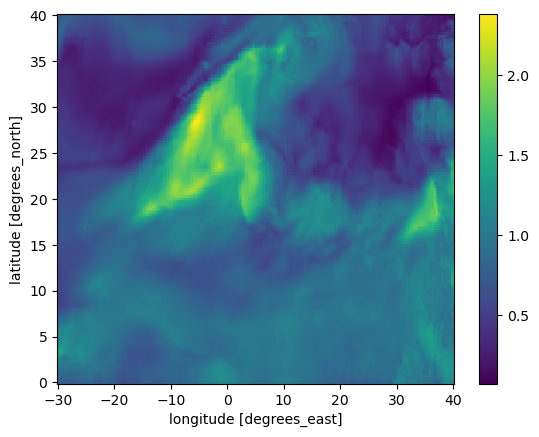

In [5]:
upper_by_lower = (FS.s_upper / FS.s_lower).mean('time')

upper_by_lower.plot()

upper_by_lower_mean = np.nanmean(upper_by_lower.to_numpy())

print('ratio of upper to lower bucket = ' + str(upper_by_lower_mean))


In [6]:
# Load data
path = 'C:/Users/rjvanderent/Documents/Moisture tracking/example-input-volta'
region = xr.open_dataarray(path + "/tagging-region-volta.nc")

output = xr.open_mfdataset("C:/Users/rjvanderent/Documents/Moisture tracking/example-input-volta/output_data/forwardtrack_1998*.nc")
#output = xr.open_mfdataset("C:/Users/rjvanderent/Documents/Moisture tracking/example-input-volta/output_data/forwardtrack_1998-07-0*.nc")
#evap = input.evap.sel(time=slice("19980701", "19980731")).mean("time").compute() * (24 *3600) # kg/m2/day
#precip = (output.p_track_lower + output.p_track_lower).mean("time").compute() # kg/m2 accumulated  (note: output frequency 1 day)

tagged_evap = output.tagged_evap.sum('time') # mm
tagged_evap_mm_day_region = tagged_evap.where(region > 0, drop=True) / 31 # mm/day (evap for this experiment during July only)
p_track = (output.p_track_upper + output.p_track_lower).sum("time") # mm
losses = output.losses.sum("time") # mm

In [7]:
# load more data
input = xr.open_mfdataset(path + '/preprocessed_data/*_fluxes_storages.nc')

fx_interest = (input.fx_upper + input.fx_lower).mean("time")
fy_interest = (input.fy_upper + input.fy_lower).mean("time")
f_hypot = np.hypot(fx_interest, fy_interest)

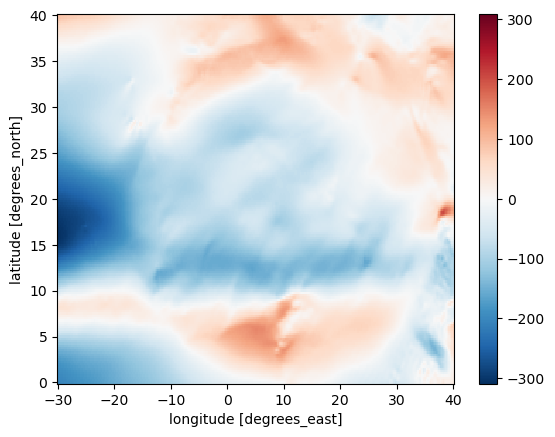

In [8]:
fx_interest.plot()

In [9]:
test_evap = output.tagged_evap.to_numpy()
test_evap[0,132,120]

4.8130794

In [10]:
test_evap = tagged_evap.to_numpy()
test_evap[132,120]

150.40866

In [11]:
test = tagged_evap.to_numpy()
test.shape

(161, 281)

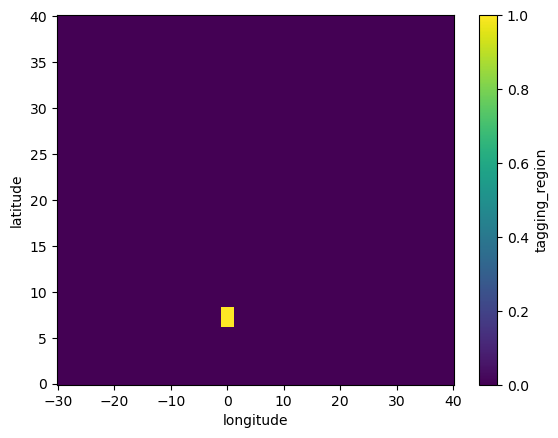

In [12]:
region.plot()

In [13]:
# get the grid cell area
def get_grid_info(ds):
    """Return grid cell area and lenght of the sides."""
    dg = 111089.56  # [m] length of 1 degree latitude
    erad = 6.371e6  # [m] Earth radius

    latitude = ds.latitude.values
    longitude = ds.longitude.values
    dx_deg = np.abs(longitude[1] - longitude[0])  # [degrees]
    dy_deg = np.abs(latitude[1] - latitude[0])  # [degrees]

    # Calculate area TODO check this calculation!
    lat_n = np.minimum(90.0, latitude + 0.5 * dx_deg)
    lat_s = np.maximum(-90.0, latitude - 0.5 * dx_deg)

    a = (
        np.pi
        / 180.0
        * erad**2
        * dx_deg
        * abs(np.sin(lat_s * np.pi / 180.0) - np.sin(lat_n * np.pi / 180.0))
    )

    # Calculate faces
    dy = dy_deg * dg  # [m] grid spacing in meridional direction
    dx_n_gridcell = dx_deg * dg * np.cos((latitude + dx_deg / 2) * np.pi / 180)
    dx_s_gridcell = dx_deg * dg * np.cos((latitude - dx_deg / 2) * np.pi / 180)
    dx = 0.5 * (dx_n_gridcell + dx_s_gridcell)  # [m] grid spacing in zonal direction
    return a, dy, dx, latitude, longitude

#load data
a_gridcell, dy, dx, latitude, longitude = get_grid_info(region)
a_gridcell_2D = np.broadcast_to(np.transpose([a_gridcell]), (len(latitude), len(longitude)))

In [14]:
latitude

array([40.  , 39.75, 39.5 , 39.25, 39.  , 38.75, 38.5 , 38.25, 38.  ,
       37.75, 37.5 , 37.25, 37.  , 36.75, 36.5 , 36.25, 36.  , 35.75,
       35.5 , 35.25, 35.  , 34.75, 34.5 , 34.25, 34.  , 33.75, 33.5 ,
       33.25, 33.  , 32.75, 32.5 , 32.25, 32.  , 31.75, 31.5 , 31.25,
       31.  , 30.75, 30.5 , 30.25, 30.  , 29.75, 29.5 , 29.25, 29.  ,
       28.75, 28.5 , 28.25, 28.  , 27.75, 27.5 , 27.25, 27.  , 26.75,
       26.5 , 26.25, 26.  , 25.75, 25.5 , 25.25, 25.  , 24.75, 24.5 ,
       24.25, 24.  , 23.75, 23.5 , 23.25, 23.  , 22.75, 22.5 , 22.25,
       22.  , 21.75, 21.5 , 21.25, 21.  , 20.75, 20.5 , 20.25, 20.  ,
       19.75, 19.5 , 19.25, 19.  , 18.75, 18.5 , 18.25, 18.  , 17.75,
       17.5 , 17.25, 17.  , 16.75, 16.5 , 16.25, 16.  , 15.75, 15.5 ,
       15.25, 15.  , 14.75, 14.5 , 14.25, 14.  , 13.75, 13.5 , 13.25,
       13.  , 12.75, 12.5 , 12.25, 12.  , 11.75, 11.5 , 11.25, 11.  ,
       10.75, 10.5 , 10.25, 10.  ,  9.75,  9.5 ,  9.25,  9.  ,  8.75,
        8.5 ,  8.25,

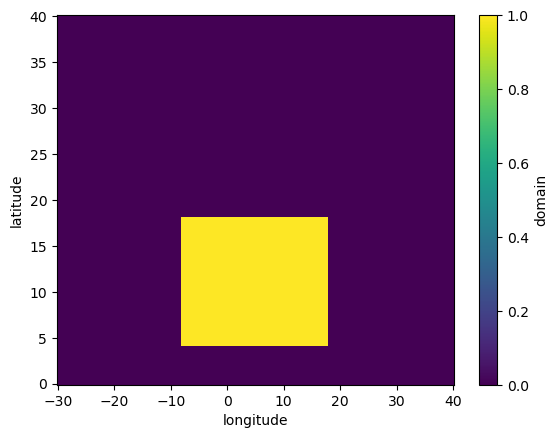

In [15]:
# define domain from 2013 paper
#-8 to 6 E, 4 to 18 N
N = np.where(latitude == 18)
S = np.where(latitude == 4)
N = np.ndarray.item(N[0])
S = np.ndarray.item(S[0])
W = np.where(longitude == -8)
E = np.where(longitude == 18)
W = np.ndarray.item(W[0])
E = np.ndarray.item(E[0])
domain = np.zeros(a_gridcell_2D.shape)
domain[N:S,W:E] = 1
domain_x = xr.full_like(region,0)
domain_x.values = domain
domain_x.name = 'domain'
domain_x.plot()

In [16]:
#compute totals
tagged_evap_m3 = tagged_evap.to_numpy() / 1000 * a_gridcell_2D
p_track_m3 = p_track.to_numpy() / 1000 * a_gridcell_2D
p_track_region_m3 = p_track_m3[region == 1]
p_track_domain_m3 = p_track_m3[domain == 1]
losses_m3 = losses.to_numpy() / 1000 * a_gridcell_2D

total_tagged_evap_m3 = np.sum(tagged_evap_m3)
total_p_track_m3 = np.sum(p_track_m3)
total_p_track_region_m3 = np.sum(p_track_region_m3)
total_p_track_domain_m3 = np.sum(p_track_domain_m3)
total_internal_losses_m3 = np.sum(losses_m3[1:-1,1:-1])
total_boundary_transport_m3 = np.sum(losses_m3[0,:]) + np.sum(losses_m3[-1,:]) + np.sum(losses_m3[1:-1,0]) + np.sum(losses_m3[1:-1,-1])

print('tagged_evap_m3 = '+ str(total_tagged_evap_m3))
print('p_track_m3 = '+ str(total_p_track_m3))
print('p_track_region_m3 = '+ str(total_p_track_region_m3))
print('p_track_domain_m3 = '+ str(total_p_track_domain_m3))
print('internal_losses_m3 = '+ str(total_internal_losses_m3))
print('boundary_transport = '+ str(total_boundary_transport_m3))

check = (total_p_track_m3 + total_internal_losses_m3 + total_boundary_transport_m3 ) / total_tagged_evap_m3 * 100
region_evap_recycling = total_p_track_region_m3 / total_tagged_evap_m3 * 100
domain_evap_recycling = total_p_track_domain_m3 / total_tagged_evap_m3 * 100
print('retrieved water = '+ str(check) + ' %')
print('attributed to sink = '+ str(total_p_track_m3 / total_tagged_evap_m3 * 100) + ' %')
print('boundary transport = '+ str(total_boundary_transport_m3 / total_tagged_evap_m3 * 100) + ' %')
print('regional evaporation recycling = '+ str(region_evap_recycling) + ' %')
print('recycling within 2013paper domain = '+ str(domain_evap_recycling) + ' %')

tagged_evap_m3 = 6328069600.0
p_track_m3 = 5422933000.0
p_track_region_m3 = 493871100.0
p_track_domain_m3 = 4260997600.0
internal_losses_m3 = 0.0
boundary_transport = 902296260.0
retrieved water = 99.95511174201965 %
attributed to sink = 85.69648265838623 %
boundary transport = 14.258633553981781 %
regional evaporation recycling = 7.804451137781143 %
recycling within 2013paper domain = 67.33487248420715 %


In [17]:
output

<xarray.Dataset>
Dimensions:                (longitude: 281, latitude: 161, time: 61, bnds: 2)
Coordinates:
  * longitude              (longitude) float32 -30.0 -29.75 -29.5 ... 39.75 40.0
  * latitude               (latitude) float32 40.0 39.75 39.5 ... 0.5 0.25 0.0
  * time                   (time) datetime64[ns] 1998-07-02 ... 1998-08-31
Dimensions without coordinates: bnds
Data variables:
    s_track_upper_restart  (time, latitude, longitude) float32 dask.array<chunksize=(1, 161, 281), meta=np.ndarray>
    s_track_lower_restart  (time, latitude, longitude) float32 dask.array<chunksize=(1, 161, 281), meta=np.ndarray>
    p_track_upper          (time, latitude, longitude) float32 dask.array<chunksize=(1, 161, 281), meta=np.ndarray>
    p_track_lower          (time, latitude, longitude) float32 dask.array<chunksize=(1, 161, 281), meta=np.ndarray>
    tagged_evap            (time, latitude, longitude) float32 dask.array<chunksize=(1, 161, 281), meta=np.ndarray>
    losses                 (time, latitude, longitude) float32 dask.array<chunksize=(1, 161, 281), meta=np.ndarray>
    gains                  (time, latitude, longitude) float32 dask.array<chunksize=(1, 161, 281), meta=np.ndarray>
    latitude_bnds          (time, latitude, bnds) float32 dask.array<chunksize=(1, 161, 2), meta=np.ndarray>
    longitude_bnds         (time, longitude, bnds) float32 dask.array<chunksize=(1, 281, 2), meta=np.ndarray>
    time_bnds              (time, bnds) datetime64[ns] dask.array<chunksize=(1, 2), meta=np.ndarray>
Attributes:
    title:              WAM2Layers forwardtracking output file
    history:            created on 2024-10-27T22:04:41Z using wam2layers vers...
    source:             Moisture tracking applied to ERA5 dataset: ECMWF Rean...
    references:         doi.org/10.5281/zenodo.7010594, doi.org/10.5194/esd-5...
    Conventions:        CF-1.6
    WAM2Layers_config:  {"filename_template":"./ERA5_{year}-{month:02d}-{day:...

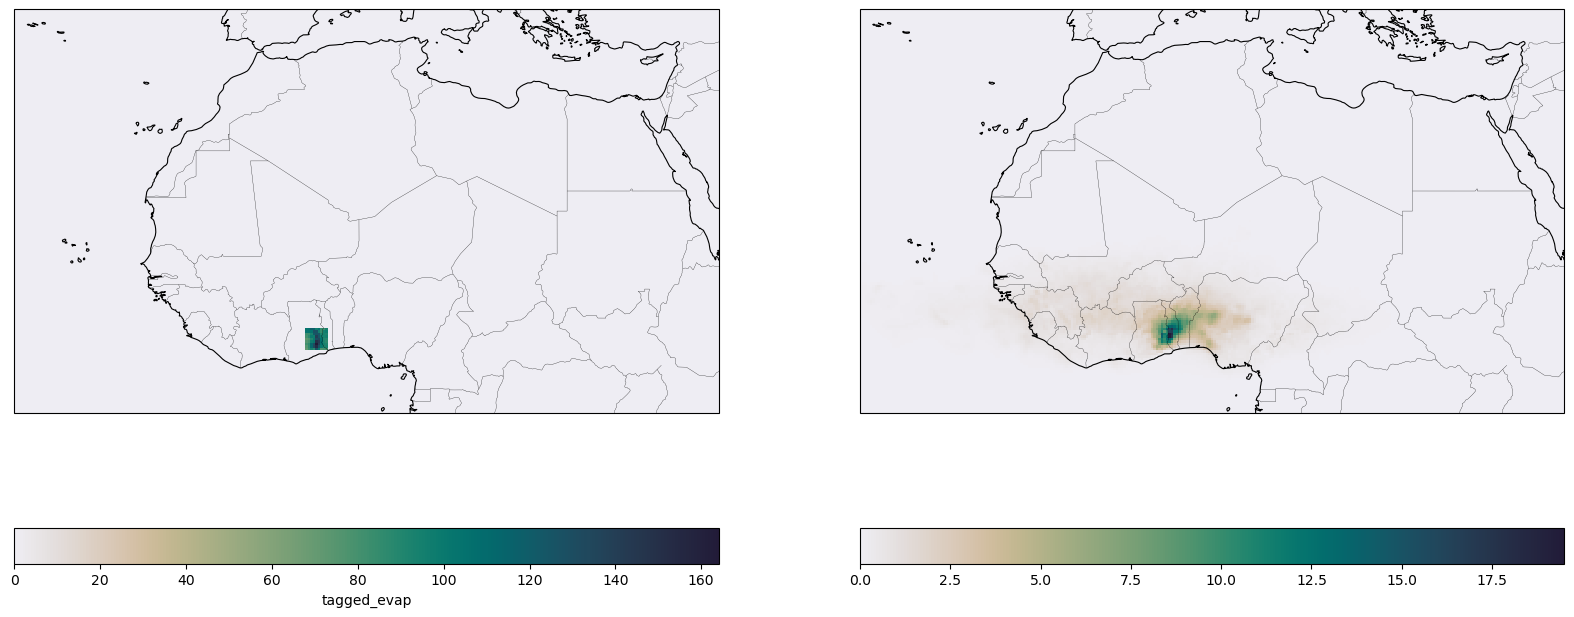

In [18]:
# Quick plot

fig, axs = plt.subplots(
    1, 2, figsize=(20, 10), subplot_kw={"projection": cartopy.crs.PlateCarree()}
)
tagged_evap.plot(ax=axs[0], cmap=cmo.rain, cbar_kwargs={"location": "bottom"})
p_track.plot(ax=axs[1], cmap=cmo.rain, cbar_kwargs={"location": "bottom"})
for ax in axs:
    ax.add_feature(cartopy.feature.COASTLINE, linewidth=0.8)
    ax.add_feature(cartopy.feature.BORDERS, linestyle="-", linewidth=0.2)

In [19]:
fy_interest

<xarray.DataArray (latitude: 161, longitude: 281)>
dask.array<mean_agg-aggregate, shape=(161, 281), dtype=float32, chunksize=(161, 281), chunktype=numpy.ndarray>
Coordinates:
  * longitude  (longitude) float32 -30.0 -29.75 -29.5 -29.25 ... 39.5 39.75 40.0
  * latitude   (latitude) float32 40.0 39.75 39.5 39.25 ... 0.75 0.5 0.25 0.0

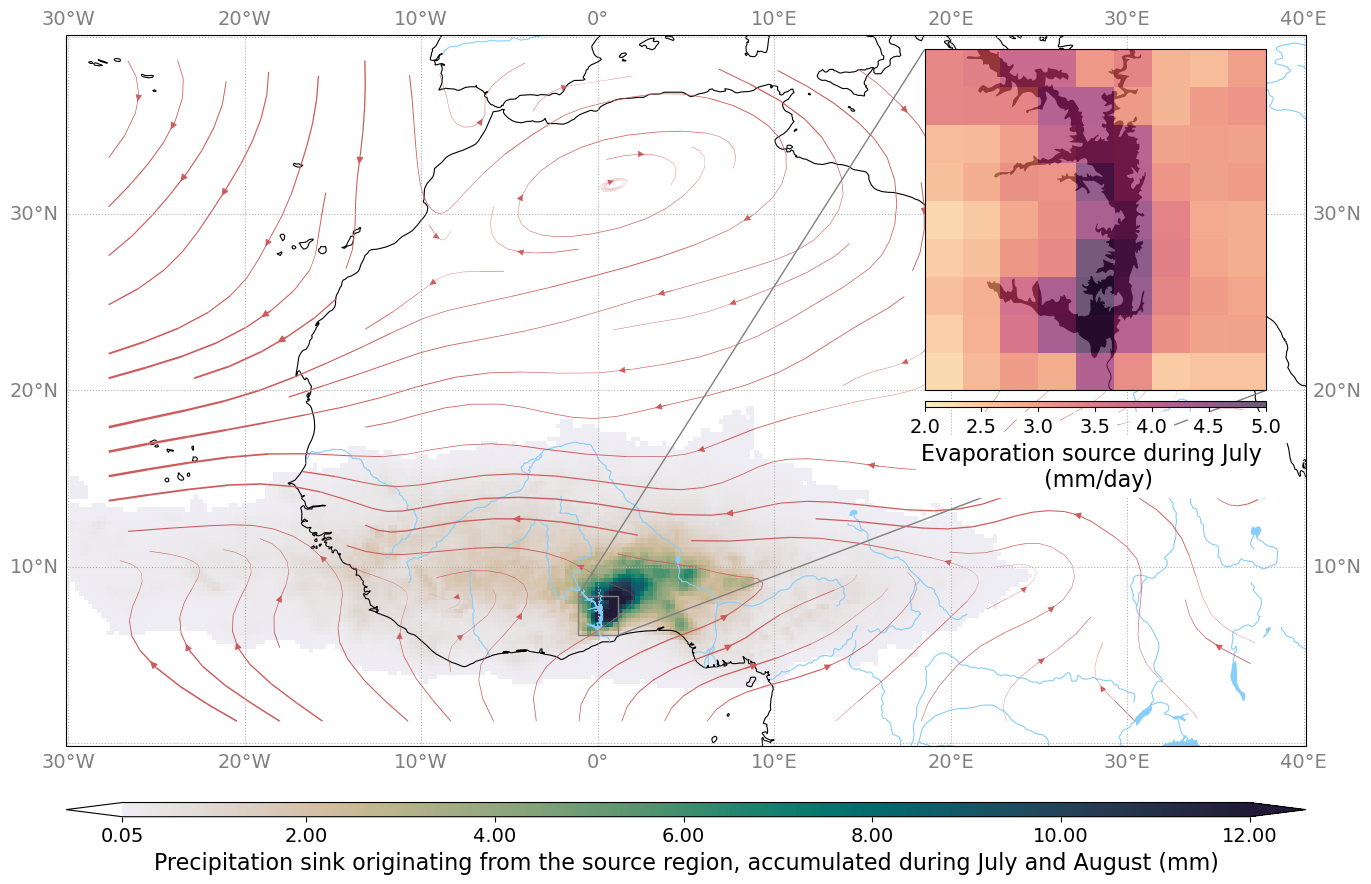

In [20]:
# Nice plot

fig = plt.figure(figsize=(16, 10))
ax1 = fig.add_subplot(111, projection=cartopy.crs.PlateCarree())

p_cmap = plt.get_cmap(cmo.rain).copy()
p_cmap.set_extremes(under='white')

gl = ax1.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, linestyle=':')
gl.xlabel_style = {'size': 14, 'color': 'gray', 'rotation':0}
gl.ylabel_style = {'size': 14, 'color': 'gray', 'rotation':0}

im1 = p_track.plot(
    ax=ax1,
    cmap=p_cmap,
    add_colorbar=False,
    vmin=0.05,
    vmax=12,
    robust=True,
)

#quiver = ax1.quiver(longitude[0::8], latitude[0::8], fx_interest[0::8,0::8], fy_interest[0::8,0::8], 
#                   transform=cartopy.crs.PlateCarree(), label='Moisture Flux',
#                   angles='xy', scale_units='xy', scale=55, color='dimgray')
#qk = ax1.quiverkey(quiver, 0.07, 1.05, 200, label='200 kg/m/s', labelpos='S', labelcolor='k', fontproperties={'size':18})
stream = ax1.streamplot(longitude, latitude, fx_interest, fy_interest, 
                   transform=cartopy.crs.PlateCarree(), color='indianred', linewidth=f_hypot.values/150, density=1)

cax1 = ax1.inset_axes([0, -0.1, 1, 0.02])
cbar1 = plt.colorbar(
    im1,
    cax1,
    orientation="horizontal",
    extend='both',
    ticks=[0.05, 2, 4, 6, 8, 10, 12],
)
cbar1.ax.tick_params(labelsize=14)
cbar1.set_label("Precipitation sink originating from the source region, accumulated during July and August (mm)", fontsize=16)

ax2 = ax1.inset_axes([0.48, 0.5, 0.7, 0.48], projection=cartopy.crs.PlateCarree())
im2 = tagged_evap_mm_day_region.plot(
    ax=ax2,
    cmap=cmo.matter,
    add_colorbar=False,
    vmin=2,
    vmax=5,
    robust=True,
    alpha=0.7,
)
cax2 = ax2.inset_axes([0, -0.05, 1, 0.02])
cbar2 = plt.colorbar(
    im2,
    cax2,
    orientation="horizontal",
    ticks= np.arange(0,5.5,0.5),
)
cbar2.ax.tick_params(labelsize=14)
cbar2.set_label("Evaporation source during July \n (mm/day)", fontsize=16, backgroundcolor='w')
#ticklabs = cbar2.ax.get_xticklabels()
#cbar2.ax.set_xticklabels(ticklabs, fontsize=9)

mark_inset(ax1, ax2, 2, 4, edgecolor='gray')

bbox = dict(ec='white', fc="white")
plt.setp(cax2.get_xticklabels(), bbox=bbox)

ax1.add_feature(cartopy.feature.COASTLINE, linewidth=0.8)
#ax1.add_feature(cartopy.feature.BORDERS, linestyle="-", linewidth=0.2)
ax1.add_feature(cartopy.feature.RIVERS, linewidth=0.8, color='lightskyblue', alpha=1)
ax1.add_feature(cartopy.feature.LAKES, linewidth=0, color='lightskyblue', alpha=1)

#ax2.add_feature(cartopy.feature.COASTLINE, linewidth=0.8)
#ax2.add_feature(cartopy.feature.BORDERS, linestyle="-", linewidth=0.2)
ax2.add_feature(cartopy.feature.RIVERS, linewidth=0.8, color='k', zorder=-10)
ax2.add_feature(cartopy.feature.LAKES, linewidth=0, color='k', zorder=-10)

plt.savefig("volta_new.png", bbox_inches="tight")
plt.show()

# Eiffel

In [22]:
# Load data
path = 'C:/Users/rjvanderent/Documents/Moisture tracking/example-input-eiffel'
region = xr.open_dataarray(path + "/region-eiffel.nc")

a_gridcell, dy, dx, latitude, longitude = get_grid_info(region)
a_gridcell_2D = np.broadcast_to(np.transpose([a_gridcell]), (len(latitude), len(longitude)))

output = xr.open_mfdataset(path + "/output/backtrack_2021*.nc")

tagged_precip = output.tagged_precip.sum('time') # mm
tagged_precip_mm = tagged_precip.where(region > 0, drop=True)
tagged_evap_region = tagged_precip.where(region > 0, drop=True) # mm
e_track = output.e_track.sum("time") # mm
losses = output.losses.sum("time") # mm

In [23]:
# load more data
input = xr.open_mfdataset(path + '/preprocessed_data/*_fluxes_storages.nc')

fx_interest = (input.fx_upper + input.fx_lower).mean("time")
fy_interest = (input.fy_upper + input.fy_lower).mean("time")
f_hypot = np.hypot(fx_interest, fy_interest)

In [24]:
latitude

array([60.  , 59.75, 59.5 , 59.25, 59.  , 58.75, 58.5 , 58.25, 58.  ,
       57.75, 57.5 , 57.25, 57.  , 56.75, 56.5 , 56.25, 56.  , 55.75,
       55.5 , 55.25, 55.  , 54.75, 54.5 , 54.25, 54.  , 53.75, 53.5 ,
       53.25, 53.  , 52.75, 52.5 , 52.25, 52.  , 51.75, 51.5 , 51.25,
       51.  , 50.75, 50.5 , 50.25, 50.  , 49.75, 49.5 , 49.25, 49.  ,
       48.75, 48.5 , 48.25, 48.  , 47.75, 47.5 , 47.25, 47.  , 46.75,
       46.5 , 46.25, 46.  , 45.75, 45.5 , 45.25, 45.  , 44.75, 44.5 ,
       44.25, 44.  , 43.75, 43.5 , 43.25, 43.  , 42.75, 42.5 , 42.25,
       42.  , 41.75, 41.5 , 41.25, 41.  , 40.75, 40.5 , 40.25, 40.  ,
       39.75, 39.5 , 39.25, 39.  , 38.75, 38.5 , 38.25, 38.  , 37.75,
       37.5 , 37.25, 37.  , 36.75, 36.5 , 36.25, 36.  , 35.75, 35.5 ,
       35.25, 35.  , 34.75, 34.5 , 34.25, 34.  , 33.75, 33.5 , 33.25,
       33.  , 32.75, 32.5 , 32.25, 32.  , 31.75, 31.5 , 31.25, 31.  ,
       30.75, 30.5 , 30.25, 30.  ], dtype=float32)

In [25]:
#compute totals
tagged_precip_m3 = tagged_precip.to_numpy() / 1000 * a_gridcell_2D
e_track_m3 = e_track.to_numpy() / 1000 * a_gridcell_2D
e_track_region_m3 = e_track_m3[region == 1]
losses_m3 = losses.to_numpy() / 1000 * a_gridcell_2D

total_tagged_precip_m3 = np.sum(tagged_precip_m3)
total_e_track_m3 = np.sum(e_track_m3)
total_e_track_region_m3 = np.sum(e_track_region_m3)
total_internal_losses_m3 = np.sum(losses_m3[1:-1,1:-1])
total_boundary_transport_m3 = np.sum(losses_m3[0,:]) + np.sum(losses_m3[-1,:]) + np.sum(losses_m3[1:-1,0]) + np.sum(losses_m3[1:-1,-1])

print('tagged_precip_m3 = '+ str(total_tagged_precip_m3))
print('e_track_m3 = '+ str(total_e_track_m3))
print('e_track_region_m3 = '+ str(total_e_track_region_m3))
print('internal_losses_m3 = '+ str(total_internal_losses_m3))
print('boundary_transport = '+ str(total_boundary_transport_m3))

check = (total_e_track_m3 + total_internal_losses_m3 + total_boundary_transport_m3 ) / total_tagged_precip_m3 * 100
region_precip_recycling = total_e_track_region_m3 / total_tagged_precip_m3 * 100
print('retrieved water = '+ str(check) + ' %')
print('attributed to source = '+ str(total_e_track_m3 / total_tagged_precip_m3 * 100) + ' %')
print('boundary transport = '+ str(total_boundary_transport_m3 / total_tagged_precip_m3 * 100) + ' %')
print('regional precipitation recycling = '+ str(region_precip_recycling) + ' %')

tagged_precip_m3 = 7689760000.0
e_track_m3 = 3254603500.0
e_track_region_m3 = 185037300.0
internal_losses_m3 = 0.0
boundary_transport = 4176757500.0
retrieved water = 96.63970470428467 %
attributed to source = 42.32386350631714 %
boundary transport = 54.31584119796753 %
regional precipitation recycling = 2.406281977891922 %


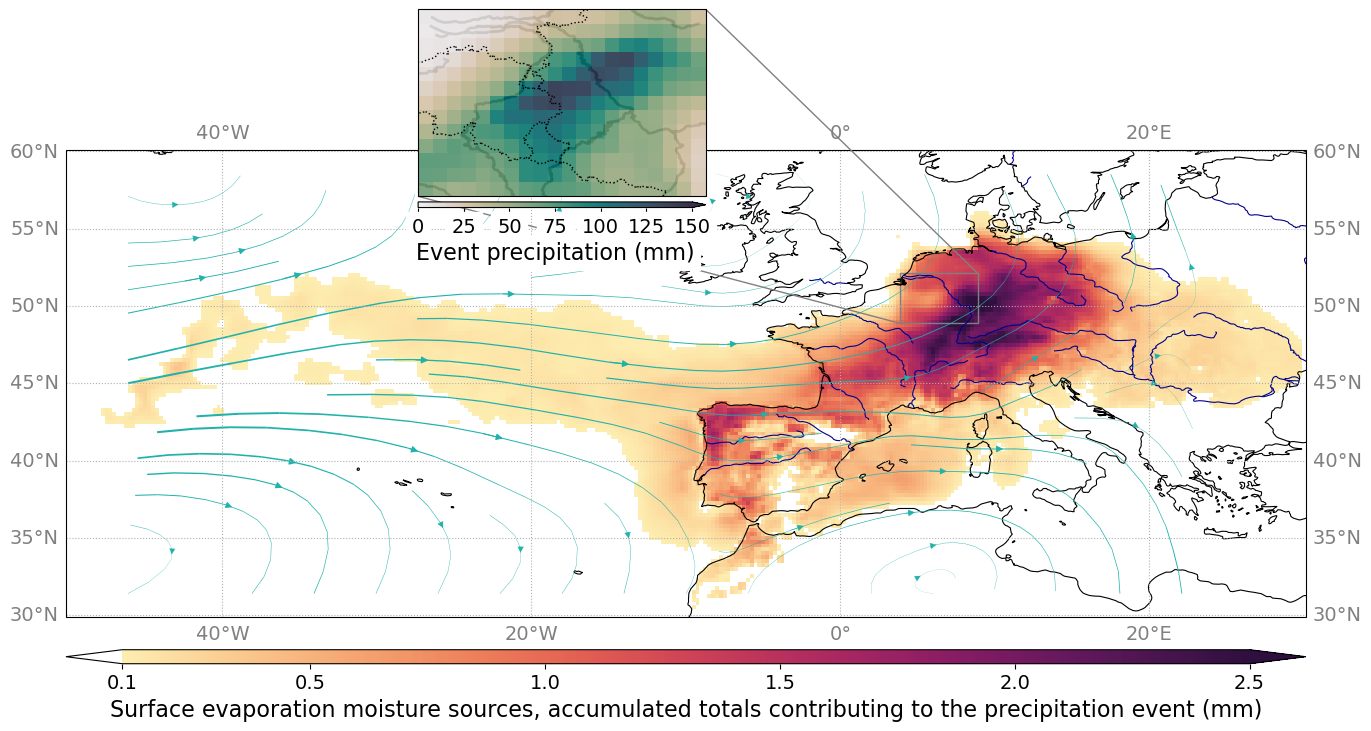

In [26]:
# Nice plot

fig2 = plt.figure(figsize=(16, 10))
ax1 = fig2.add_subplot(111, projection=cartopy.crs.PlateCarree())

e_cmap = plt.get_cmap(cmo.matter).copy()
e_cmap.set_extremes(under='white')

gl = ax1.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, linestyle=':')
gl.xlabel_style = {'size': 14, 'color': 'gray', 'rotation':0}
gl.ylabel_style = {'size': 14, 'color': 'gray', 'rotation':0}

im1 = e_track.plot(
    ax=ax1,
    cmap=e_cmap,
    add_colorbar=False,
    vmin=0.1,
    vmax=2.5,
    robust=True,
)

stream = ax1.streamplot(longitude, latitude, fx_interest, fy_interest, 
                   transform=cartopy.crs.PlateCarree(), color='lightseagreen',linewidth=f_hypot.values/300, density=0.7)

cax1 = ax1.inset_axes([0, -0.1, 1, 0.03])
cbar1 = plt.colorbar(
    im1,
    cax1,
    orientation="horizontal",
    extend='both',
    ticks=[0.1, 0.5, 1, 1.5, 2, 2.5],
)
cbar1.ax.tick_params(labelsize=14)
cbar1.set_label("Surface evaporation moisture sources, accumulated totals contributing to the precipitation event (mm)", fontsize=16)

ax2 = ax1.inset_axes([0.2, 0.9, 0.4, 0.4], projection=cartopy.crs.PlateCarree())
im2 = tagged_precip_mm.plot(
    ax=ax2,
    cmap=cmo.rain,
    add_colorbar=False,
    vmin=0,
    vmax=150,
    robust=True,
    alpha=0.9
)

cax2 = ax2.inset_axes([0, -0.06, 1, 0.03])
cbar2 = plt.colorbar(
    im2,
    cax2,
    orientation="horizontal",
    extend='max',
    ticks= np.arange(0,151,25),
)
cbar2.ax.tick_params(labelsize=14)
cbar2.set_label("Event precipitation (mm)", fontsize=16, backgroundcolor='w')

mark_inset(ax1, ax2, 1, 3, edgecolor='gray')

bbox = dict(ec='white', fc="white")
plt.setp(cax2.get_xticklabels(), bbox=bbox)

ax1.add_feature(cartopy.feature.COASTLINE, linewidth=0.8)
#ax1.add_feature(cartopy.feature.BORDERS, linestyle="-", linewidth=0.2)
ax1.add_feature(cartopy.feature.RIVERS, linewidth=0.8, color='darkblue', alpha=1)
#ax1.add_feature(cartopy.feature.LAKES, linewidth=0, color='lightskyblue', alpha=1)

#ax2.add_feature(cartopy.feature.COASTLINE, linewidth=0.8)
ax2.add_feature(cartopy.feature.BORDERS, linestyle=":", linewidth=1)
ax2.add_feature(cartopy.feature.RIVERS, linewidth=2, color='k', zorder=-10)
#ax2.add_feature(cartopy.feature.LAKES, linewidth=0, color='k', zorder=-10)

plt.savefig("eiffel_new.png", bbox_inches="tight")
plt.show()

In [27]:
np.max(e_track.values)

3.0684404